# Assignment 6 Eran Rehani 207823063
# 1D Lagrangian Hydrodynamics: Sod Shock Tube

Sod initial condition evolved to $t=2.5$ on four grids ($N=34,100,334,1000$). Feature speeds and energy conservation compared against the exact Riemann solution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

#  Physical / problem parameters (cgs units) 
GAMMA   = 1.4  # ideal-gas adiabatic index
SIGMA   = 3.0 # artificial-viscosity coefficient (sensible range 2-4)
X_L     = 0.0 # left wall position
X_R     = 16.0  # right wall position
X_DIAPH = 8.0    # diaphragm (initial discontinuity) location
T_END   = 2.5  # final simulation time
CFL     = 0.2   # Courant number 
MAX_DRHO  = 0.05 # max relative density change per step (5-10%)
DT_GROWTH = 1.1   # max relative growth of dt between steps (keeps changes gentle)

# Initial left/right states (u, rho, p)
RHO_L, U_L, P_L = 1.0,   0.0, 1.0
RHO_R, U_R, P_R = 0.125, 0.0, 0.1

# Resolutions to run (number of cells / intervals)
N_LIST = [34, 100, 334, 1000]

## 1. Setup

Ideal gas, $p=(\gamma-1)\rho e$. Staggered Lagrangian grid: cells $(i-\tfrac12)$ hold $\rho,e,p$; vertices $(i)$ hold $x,u,a$. Cell mass $m_{i-1/2}=\rho_{i-1/2}V_{i-1/2}$ is conserved. Rigid walls at both ends.

Initial condition:
$$(\rho,u,p)=\begin{cases}(1,\,0,\,1) & x<8\\(0.125,\,0,\,0.1) & x>8.\end{cases}$$
Three wave structures emerge: **shock** (jumps in $\rho,u,p$), **contact** (jump in $\rho$ only), **rarefaction fan** (smooth, with head and tail).

## 2. The Difference Equations ( From summary 19)

Staggered grid: cells $(i-\tfrac12)$ hold $\rho,e,p$; vertices $(i)$ hold $x,u,a$. Cell masses fixed; walls at $u_0=u_N=0$.

Predictor (positions and densities):
$$u_i^{n+1/2}=u_i^n+\tfrac{\Delta t}{2}a_i^n,\qquad x_i^{n+1}=x_i^n+\Delta t\,u_i^{n+1/2},$$
$$V_{i-1/2}^{n+1}=x_i^{n+1}-x_{i-1}^{n+1},\qquad \rho_{i-1/2}^{n+1}=m_{i-1/2}/V_{i-1/2}^{n+1}.$$

Artificial viscosity (compression only, adds to $p$ everywhere $p$ appears):
$$q_{i-1/2}^{n+1}=\begin{cases}\sigma\rho^{n+1}(u_{i-1}^{n+1/2}-u_i^{n+1/2})^2 & u_i < u_{i-1}\\0\end{cases}$$

Energy and EoS (coupled; solved algebraically for ideal gas with $\Delta V=V^{n+1}-V^n$):
$$e^{n+1}=\frac{e^n - \frac{\Delta V}{2m}(p^n+q^n+q^{n+1})}{1+\frac{(\gamma-1)\Delta V}{2V^{n+1}}},\qquad p^{n+1}=(\gamma-1)\rho^{n+1}e^{n+1}.$$

Accelerations and corrector:
$$a_i^{n+1}=-2\frac{(p+q)_{i+1/2}^{n+1}-(p+q)_{i-1/2}^{n+1}}{m_{i-1/2}+m_{i+1/2}},\qquad u_i^{n+1}=u_i^{n+1/2}+\tfrac{\Delta t}{2}a_i^{n+1}.$$

Time step: $\Delta t\le\mathrm{CFL}\cdot\min(\Delta x/c)$, also capped by the density-change limit and a growth factor.

In [ ]:
def sound_speed(p, rho):
    """Ideal-gas sound speed c = sqrt(gamma p / rho)."""
    return np.sqrt(GAMMA * np.maximum(p, 1e-30) / rho)


def init_state(N):
    """Initial Sod state on N cells over [X_L, X_R]; diaphragm sits on a vertex (N even)."""
    x  = np.linspace(X_L, X_R, N + 1)  # N+1 vertices
    xc = 0.5 * (x[:-1] + x[1:])  # cell centres
    rho = np.where(xc < X_DIAPH, RHO_L, RHO_R)
    p   = np.where(xc < X_DIAPH, P_L,   P_R)
    e   = p / ((GAMMA - 1.0) * rho)   # specific internal energy
    V   = np.diff(x)
    m   = rho * V  # fixed cell masses
    u   = np.zeros(N + 1) # vertex velocities
    a   = np.zeros(N + 1) # vertex accelerations
    q   = np.zeros(N)  # artificial viscosity per cell
    return dict(x=x, u=u, a=a, rho=rho, e=e, p=p, q=q, m=m, V=V)

In [ ]:
def step(s, dt):
    """Advance the staggered Lagrangian state by one time step dt."""
    x, u, a = s['x'], s['u'], s['a']
    rho, e, p, q, m, V = s['rho'], s['e'], s['p'], s['q'], s['m'], s['V']

    # (1)-(2) predictor velocity and new vertex positions
    u_half = u + 0.5 * dt * a
    u_half[0] = 0.0; u_half[-1] = 0.0    # rigid walls
    x_new = x + dt * u_half

    # (3)-(4) new volumes and densities
    V_new   = np.diff(x_new)
    rho_new = m / V_new

    # artificial viscosity at n+1 (compression only)
    du    = u_half[:-1] - u_half[1:]   # u_{i-1} - u_i
    q_new = np.where(du > 0.0, SIGMA * rho_new * du**2, 0.0)

    # (5)-(6) algebraic energy + EoS update for an ideal gas
    dV    = V_new - V
    e_new = (e - (dV / (2.0 * m)) * (p + q + q_new)) / (1.0 + (GAMMA - 1.0) * dV / (2.0 * V_new))
    p_new = (GAMMA - 1.0) * rho_new * e_new

    # (7) accelerations from total pressure (p + q); walls held at 0
    pq    = p_new + q_new
    a_new = np.zeros_like(a)
    a_new[1:-1] = -2.0 * (pq[1:] - pq[:-1]) / (m[:-1] + m[1:])

    # (8) corrector velocity
    u_new = u_half + 0.5 * dt * a_new
    u_new[0] = 0.0; u_new[-1] = 0.0

    s.update(x=x_new, u=u_new, a=a_new, rho=rho_new, e=e_new, p=p_new, q=q_new, V=V_new)
    return s

In [ ]:
def compute_dt(s, dt_prev, t, t_target):
    """Time step from Courant + a density-change limit, with gentle growth and target clamping."""
    dx = np.diff(s['x'])
    c  = sound_speed(s['p'], s['rho'])
    dt = CFL * np.min(dx / c)  # Courant condition

    # density-change limit: |drho/rho| ~ |u_i - u_{i-1}|/V * dt <= MAX_DRHO
    du = np.abs(s['u'][1:] - s['u'][:-1])
    moving = du > 1e-12
    if np.any(moving):
        dt = min(dt, MAX_DRHO * np.min(dx[moving] / du[moving]))

    if dt_prev > 0.0:
        dt = min(dt, DT_GROWTH * dt_prev)
    dt = min(dt, t_target - t)
    return dt


def total_energy(s):
    """Total energy = internal (sum over cells of e*m) + kinetic (sum over vertices of m_v*u^2/2)."""
    E_int = np.sum(s['e'] * s['m'])
    m = s['m']
    M = np.empty_like(s['u']) # vertex masses
    M[1:-1] = 0.5 * (m[:-1] + m[1:])
    M[0]    = 0.5 * m[0]  # end vertices own half a cell
    M[-1]   = 0.5 * m[-1]
    E_kin = 0.5 * np.sum(M * s['u']**2)
    return E_int + E_kin

In [30]:
def run(N, snap_times):
    """Integrate resolution N to T_END, storing snapshots at the requested times.

    Returns (snaps, energy_fraction) where snaps[t] = dict(xc, rho, p, u) and
    energy_fraction = (E_end - E_start) / E_start.
    """
    s = init_state(N)
    E_start = total_energy(s)
    targets = sorted(set(list(snap_times) + [T_END]))

    snaps = {}
    t, dt_prev = 0.0, 0.0
    for t_target in targets:
        while t < t_target - 1e-12:
            dt = compute_dt(s, dt_prev, t, t_target)
            step(s, dt)
            t += dt
            dt_prev = dt
        xc = 0.5 * (s['x'][:-1] + s['x'][1:])
        snaps[t_target] = dict(xc=xc.copy(), rho=s['rho'].copy(),
                               p=s['p'].copy(), u=s['u'].copy())

    # positivity sanity check
    assert np.all(s['rho'] > 0) and np.all(s['p'] > 0), "non-physical state encountered"
    E_end = total_energy(s)
    return snaps, (E_end - E_start) / E_start

## 3. The Exact Sod Solution (for checking)

A single jump has a known exact answer depending only on $\xi=(x-8)/t$. The middle-region pressure
$p_*$ is the root of
$$f(p_*)=f_L(p_*)+f_R(p_*)+(u_R-u_L)=0,$$
where $f_K$ is a rarefaction term ($p_*<p_K$) or a shock term ($p_*>p_K$). From $p_*$ come the
contact speed $u_*$, the densities, and the four speeds: rarefaction **head** ($u_L-c_L$) and
**tail** ($u_*-c_{*L}$), **contact** ($u_*$), and **shock**.

In [ ]:
def _f_branch(p, pK, rhoK, cK):
    """Rarefaction/shock function for one side of the Riemann problem."""
    if p > pK:  # shock
        A = 2.0 / ((GAMMA + 1.0) * rhoK)
        B = (GAMMA - 1.0) / (GAMMA + 1.0) * pK
        return (p - pK) * np.sqrt(A / (p + B))
    else:       # rarefaction
        return 2.0 * cK / (GAMMA - 1.0) * ((p / pK) ** ((GAMMA - 1.0) / (2.0 * GAMMA)) - 1.0)


def sod_exact():
    """Solve the Sod Riemann problem; return star state, feature speeds, and a profile sampler."""
    cL = sound_speed(P_L, RHO_L)
    cR = sound_speed(P_R, RHO_R)

    F = lambda p: _f_branch(p, P_L, RHO_L, cL) + _f_branch(p, P_R, RHO_R, cR) + (U_R - U_L)
    p_star = brentq(F, 1e-8, 10.0)
    u_star = 0.5 * (U_L + U_R) + 0.5 * (_f_branch(p_star, P_R, RHO_R, cR)
                                        - _f_branch(p_star, P_L, RHO_L, cL))

    rho_starL = RHO_L * (p_star / P_L) ** (1.0 / GAMMA)  # left of contact (rarefaction)
    c_starL   = cL * (p_star / P_L) ** ((GAMMA - 1.0) / (2.0 * GAMMA))
    rho_starR = RHO_R * ((p_star / P_R + (GAMMA - 1.0) / (GAMMA + 1.0)) /
                         ((GAMMA - 1.0) / (GAMMA + 1.0) * p_star / P_R + 1.0))  # behind shock
    speeds = dict(
        head    = U_L - cL,
        tail    = u_star - c_starL,
        contact = u_star,
        shock   = U_R + cR * np.sqrt((GAMMA + 1.0) / (2.0 * GAMMA) * (p_star / P_R)
                                     + (GAMMA - 1.0) / (2.0 * GAMMA)),
    )

    def profile(x, t):
        """Exact (rho, u, p) at positions x and time t > 0, centred on the diaphragm."""
        xi = (np.asarray(x, float) - X_DIAPH) / t
        rho = np.empty_like(xi); u = np.empty_like(xi); p = np.empty_like(xi)
        for k, s in enumerate(xi):
            if s < speeds['head']: # undisturbed left
                rho[k], u[k], p[k] = RHO_L, U_L, P_L
            elif s < speeds['tail']: # inside rarefaction fan
                u[k]   = 2.0 / (GAMMA + 1.0) * (cL + (GAMMA - 1.0) / 2.0 * U_L + s)
                c      = cL - (GAMMA - 1.0) / 2.0 * (u[k] - U_L)
                rho[k] = RHO_L * (c / cL) ** (2.0 / (GAMMA - 1.0))
                p[k]   = P_L * (c / cL) ** (2.0 * GAMMA / (GAMMA - 1.0))
            elif s < speeds['contact']:  # star-left
                rho[k], u[k], p[k] = rho_starL, u_star, p_star
            elif s < speeds['shock']:   # star-right
                rho[k], u[k], p[k] = rho_starR, u_star, p_star
            else:  # undisturbed right
                rho[k], u[k], p[k] = RHO_R, U_R, P_R
        return rho, u, p

    return dict(p_star=p_star, u_star=u_star, rho_starL=rho_starL, rho_starR=rho_starR,
                speeds=speeds, profile=profile)


EXACT = sod_exact()
print("Exact Sod solution:")
print(f"  p*   = {EXACT['p_star']:.5f}   u* = {EXACT['u_star']:.5f}")
print(f"  rho*_L = {EXACT['rho_starL']:.5f}   rho*_R = {EXACT['rho_starR']:.5f}")
print("  feature speeds [cm/s]:")
for k in ['head', 'tail', 'contact', 'shock']:
    print(f"    {k:>8}: {EXACT['speeds'][k]:+.5f}")

Exact Sod solution:
  p*   = 0.30313   u* = 0.92745
  rho*_L = 0.42632   rho*_R = 0.26557
  feature speeds [cm/s]:
        head: -1.18322
        tail: -0.07027
     contact: +0.92745
       shock: +1.75216


These are the reference values. The tail speed ($-0.07$) is nearly zero, which makes it the hardest feature to measure numerically.

$p_* \approx 0.303$, $u_* \approx 0.927$; shock $\approx +1.75$, contact $\approx +0.93$, head $\approx -1.18$, tail $\approx -0.07$.

## 4. Getting the Speeds from the Simulation

Each speed is $(x(2.2)-x(2.0))/0.2$, with feature positions found by linear interpolation (level crossing):

- Shock: rightmost crossing of $p=\tfrac12(p_*+p_R)$
- Contact: crossing of $\rho=\tfrac12(\rho_{*L}+\rho_{*R})$ between fan and shock
- Head / tail: track $0.995\rho_L$ and $1.005\rho_{*L}$ (fan is self-similar, so a fixed density moves at fixed speed)

In [21]:
def _cross(x, y, level, lo, hi, from_right=False):
    """Linearly-interpolated x where y crosses `level` within [lo, hi]; scan direction selectable."""
    mask = (x >= lo) & (x <= hi)
    xs, ys = x[mask], y[mask]
    idx = range(len(xs) - 2, -1, -1) if from_right else range(len(xs) - 1)
    for k in idx:
        a, b = ys[k], ys[k + 1]
        if (a - level) * (b - level) <= 0.0 and a != b:
            f = (level - a) / (b - a)
            return xs[k] + f * (xs[k + 1] - xs[k])
    return np.nan


def feature_positions(snap):
    """Locate shock, contact, and rarefaction head/tail on one density snapshot."""
    x, rho, p = snap['xc'], snap['rho'], snap['p']
    rsL, rsR = EXACT['rho_starL'], EXACT['rho_starR']
    p_star, P_right = EXACT['p_star'], P_R

    x_shock   = _cross(x, p,   0.5 * (p_star + P_right), X_DIAPH, x.max(), from_right=True)
    x_contact = _cross(x, rho, 0.5 * (rsL + rsR), X_DIAPH - 0.5, x_shock - 0.05, from_right=True)
    x_head    = _cross(x, rho, 0.995 * RHO_L, x.min(), X_DIAPH)
    x_tail    = _cross(x, rho, 1.005 * rsL,  x.min(), x_contact - 0.05)
    return dict(head=x_head, tail=x_tail, contact=x_contact, shock=x_shock)


def measure_speeds(snaps):
    """Feature speeds from the t=2.0 and t=2.2 snapshots: (x(2.2) - x(2.0)) / 0.2."""
    p20 = feature_positions(snaps[2.0])
    p22 = feature_positions(snaps[2.2])
    return {k: (p22[k] - p20[k]) / 0.2 for k in p20}

## 5. Run

In [ ]:
results = {}
for N in N_LIST:
    snaps, e_frac = run(N, snap_times=[2.0, 2.2])
    speeds = measure_speeds(snaps)
    results[N] = dict(snaps=snaps, e_frac=e_frac, speeds=speeds)
    print(f"N = {N:5d}  done | energy fraction = {e_frac:+.3e}")

N =    34  done - energy fraction = +6.388e-05
N =   100  done - energy fraction = +2.119e-05
N =   334  done - energy fraction = +6.324e-06
N =  1000  done - energy fraction = +2.107e-06


Energy drift drops roughly 3× each time $N$ goes up 3×, consistent with first-order convergence. All runs stay positive throughout.

## 6. Density at $t=2.5$

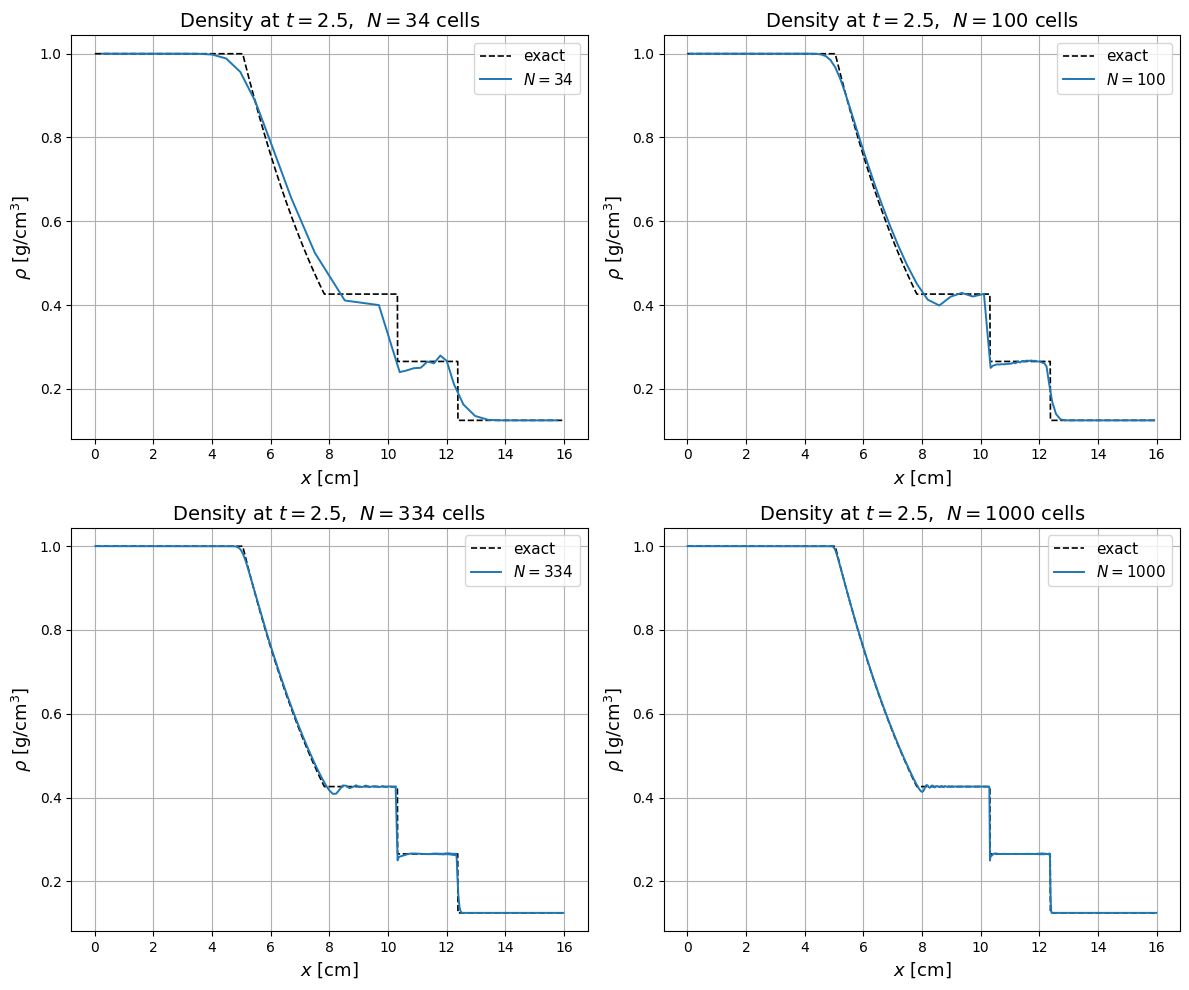

In [23]:
x_fine = np.linspace(X_L, X_R, 2000)
rho_ex, _, _ = EXACT['profile'](x_fine, T_END)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, N in zip(axes.ravel(), N_LIST):
    snap = results[N]['snaps'][T_END]
    ax.plot(x_fine, rho_ex, 'k--', lw=1.2, label='exact')
    ax.plot(snap['xc'], snap['rho'], '-', lw=1.4, label=f'$N={N}$')
    ax.set_xlabel(r'$x$ [cm]', fontsize=13)
    ax.set_ylabel(r'$\rho$ [g/cm$^3$]', fontsize=13)
    ax.set_title(rf'Density at $t=2.5$,  $N={N}$ cells', fontsize=14)
    ax.grid(True)
    ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

The fan matches the exact solution even on $N=34$. The shock and contact are smeared over several cells at coarse resolution and sharpen with $N$, but never become true jumps because of the viscosity.

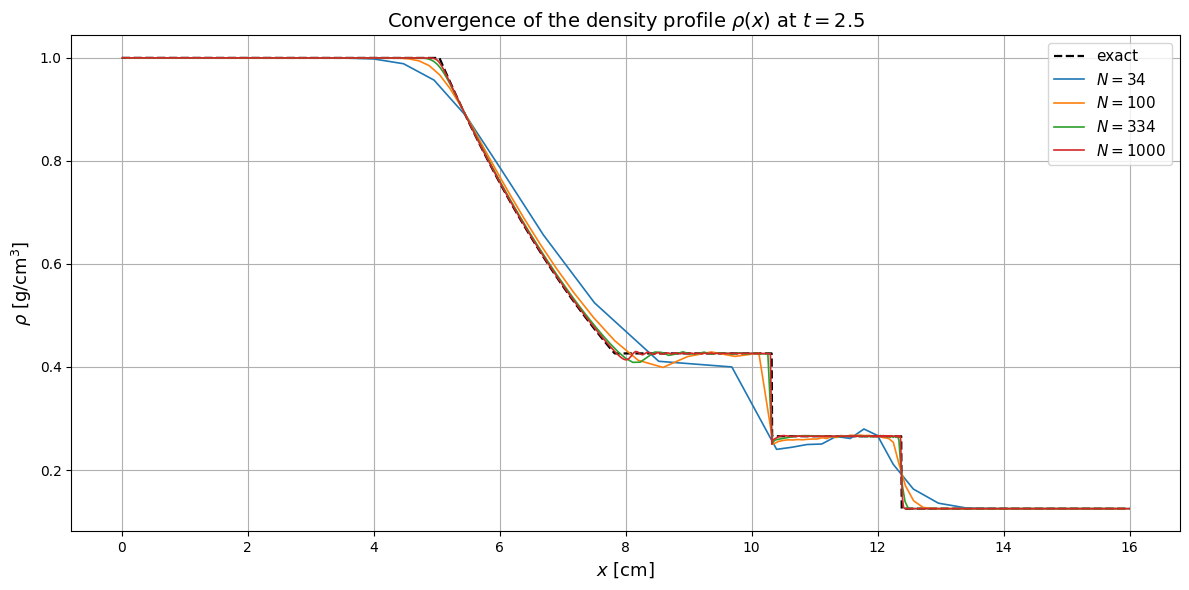

In [24]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_fine, rho_ex, 'k--', lw=1.6, label='exact')
for N in N_LIST:
    snap = results[N]['snaps'][T_END]
    ax.plot(snap['xc'], snap['rho'], '-', lw=1.2, label=f'$N={N}$')
ax.set_xlabel(r'$x$ [cm]', fontsize=13)
ax.set_ylabel(r'$\rho$ [g/cm$^3$]', fontsize=13)
ax.set_title(r'Convergence of the density profile $\rho(x)$ at $t=2.5$', fontsize=14)
ax.grid(True)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

All four curves overlap on the fan; the spread is only visible at the shock and contact, where finer grids converge toward the dashed exact curve.

## 7. Results Table

In [25]:
keys = ['shock', 'contact', 'head', 'tail']
labels = {'shock': 'v_shock', 'contact': 'v_contact', 'head': 'v_rare_head', 'tail': 'v_rare_tail'}

print(f"{'N':>6} {'dx':>8} {'energy frac':>13} "
      f"{'v_shock':>10} {'v_contact':>11} {'v_rare_head':>13} {'v_rare_tail':>13}")
for N in N_LIST:
    r  = results[N]
    dx = (X_R - X_L) / N
    sp = r['speeds']
    print(f"{N:>6} {dx:>8.4f} {r['e_frac']:>13.3e} "
          f"{sp['shock']:>10.4f} {sp['contact']:>11.4f} {sp['head']:>13.4f} {sp['tail']:>13.4f}")
es = EXACT['speeds']
print(f"{'exact':>6} {'':>8} {'':>13} "
      f"{es['shock']:>10.4f} {es['contact']:>11.4f} {es['head']:>13.4f} {es['tail']:>13.4f}")

     N       dx   energy frac    v_shock   v_contact   v_rare_head   v_rare_tail
    34   0.4706     6.388e-05     1.7949      1.0459       -1.2926       -0.4954
   100   0.1600     2.119e-05     1.7166      0.9414       -1.1454        0.0238
   334   0.0479     6.324e-06     1.7626      0.9284       -1.1819       -0.0756
  1000   0.0160     2.107e-06     1.7530      0.9274       -1.1761       -0.0739
 exact                            1.7522      0.9275       -1.1832       -0.0703


Shock, contact, and head are within a few percent on all but the coarsest grid. The tail ($\approx-0.07$, barely moving) only resolves at $N=334+$.

## 8. Checks

(a) Energy: $|(E_\text{end}-E_\text{start})/E_\text{start}|$ should fall with $N$; log-log slope gives the convergence order.

(b) Speeds: shock, contact, and head should land within $\sim1\%$ on fine grids. The tail ($\approx-0.07$, barely moving) needs $N\ge334$ to resolve.

(c) Walls: the shock reaches $x\approx12.4$ at $t=2.5$, well inside the box ($x_R=16$), so walls don't interfere.

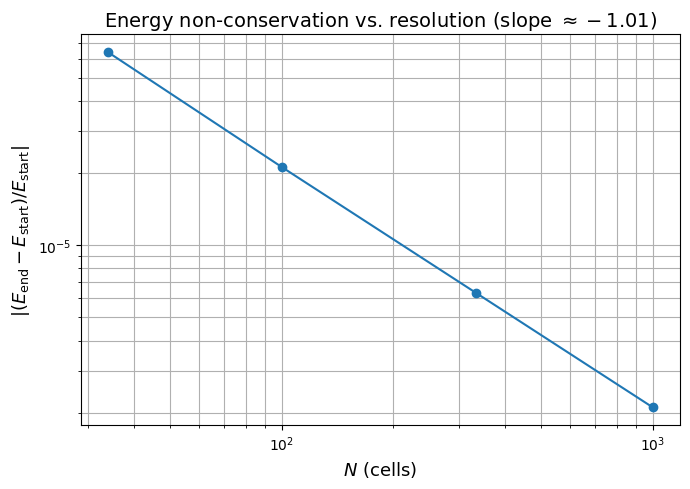

Relative error in feature speeds vs. exact:
     N      shock    contact       head       tail
    34     2.44%    12.77%     9.24%   605.01%
   100     2.03%     1.50%     3.20%   133.89%
   334     0.59%     0.11%     0.11%     7.58%
  1000     0.05%     0.01%     0.60%     5.11%

Shock reaches x = 12.38 cm at t = 2.5 (< 16.0): OK, walls inactive
Energy non-conservation decreasing with N: yes


In [26]:
# (a) energy-conservation convergence
Ns    = np.array(N_LIST, dtype=float)
efrac = np.array([abs(results[N]['e_frac']) for N in N_LIST])
slope = np.polyfit(np.log(Ns), np.log(efrac), 1)[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(Ns, efrac, 'o-', lw=1.5)
ax.set_xlabel(r'$N$ (cells)', fontsize=13)
ax.set_ylabel(r'$|(E_{\rm end}-E_{\rm start})/E_{\rm start}|$', fontsize=13)
ax.set_title(rf'Energy non-conservation vs. resolution (slope $\approx {slope:.2f}$)', fontsize=14)
ax.grid(True, which='both')
plt.tight_layout()
plt.show()

# (b) wave-speed errors vs analytic
print("Relative error in feature speeds vs. exact:")
print(f"{'N':>6} {'shock':>10} {'contact':>10} {'head':>10} {'tail':>10}")
for N in N_LIST:
    sp = results[N]['speeds']
    errs = {k: abs(sp[k] - EXACT['speeds'][k]) / abs(EXACT['speeds'][k]) for k in keys}
    print(f"{N:>6} " + " ".join(f"{errs[k]:>9.2%}" for k in keys))

# (c) wall non-interaction check
shock_reach = X_DIAPH + EXACT['speeds']['shock'] * T_END
print(f"\nShock reaches x = {shock_reach:.2f} cm at t = {T_END} (< {X_R}): "
      f"{'OK, walls inactive' if shock_reach < X_R else 'WALL INTERACTION!'}")
print(f"Energy non-conservation decreasing with N: "
      f"{'yes' if np.all(np.diff(efrac) < 0) else 'not strictly'}")

Energy error $\sim N^{-1}$ (log-log slope $\approx-1$). Speed errors shrink with $N$; tail settles on fine grids. Shock reaches $x\approx12.4 < 16$, so walls never interfere.

## 9. Conclusion

The code captures all three wave structures. Speeds converge to the exact values; energy drift falls $\sim N^{-1}$. Viscosity smears the shock and contact over a few cells, but they sharpen noticeably from $N=34$ to $N=1000$.